# E-commerce KPI and Retention Analysis

## Business Objective
Understand user acquisition performance, retention patterns, and funnel conversion in order to identify growth opportunities.

## Dataset
Synthetic e-commerce dataset including users, orders, and event tracking data.

## Key Questions
1. Which acquisition channels generate the most revenue?
2. Where do users drop off in the purchase funnel?
3. What are the retention patterns of customer cohorts?

## Methods
- SQL (DuckDB)
- Pandas analysis
- Cohort retention analysis
- Funnel conversion analysis
- Visualization using Matplotlib

##### Data Loading Section

In [12]:
import duckdb
import pandas as pd

# Load dataset
users = pd.read_csv("../data/users.csv")
orders = pd.read_csv("../data/orders.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])
order_items = pd.read_csv("../data/order_items.csv")
events = pd.read_csv("../data/events.csv")
events["event_ts"] = pd.to_datetime(events["event_ts"])

# Register dataframe as DuckDB table
con = duckdb.connect()
con.register("users", users)
con.register("orders", orders)
con.register("order_items", order_items)
con.register("events", events)

##### Query 
We compute total number of users.

In [3]:
# Run SQL
query = """
SELECT COUNT(*) AS n_users FROM users
"""

result = con.execute(query).df()
result.head()

,n_users
0,5000


##### Insight
5000 users signed up.

--------------------------------------------------------------------------------------------------------------------------------

##### Query 
We compute total revenue in completed orders.

In [4]:
query = """
SELECT SUM(revenue) AS Completed_Revenue FROM orders WHERE order_status='completed'
"""

result = con.execute(query).df()
result.head()

,Completed_Revenue
0,253341.19


##### Insight
The total revenue, excluding the cancelled and returned orders, is 253341.19.

--------------------------------------------------------------------------------------------------------------------------------

##### Query 
We want to see total revenue on completed orders per acquisition channel.

In [9]:
query = """
SELECT u.acquisition_channel AS acquisition_channel, SUM(revenue) AS total_revenue
FROM orders o
JOIN users u
    on o.user_id = u.user_id
WHERE o.order_status='completed'
GROUP BY(u.acquisition_channel)
ORDER BY total_revenue DESC;
"""

result = con.execute(query).df()
result.head()

,acquisition_channel,total_revenue
0,Organic Search,76547.61
1,Paid Search,55217.09
2,Email,34157.76
3,Social,32443.21
4,Direct,22645.92


##### Insight
We can see the total revenues for five different acquisition channels. The highest revenue is acquired from Organic Search.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
We compute conversion rate which the ratio of the users who made at least one completed order to the total users count.

In [17]:
query = """
SELECT COUNT(DISTINCT o.user_id)/COUNT(u.user_id) AS conversion_rate
FROM orders o
JOIN users u
    on o.user_id=u.user_id
WHERE o.order_status='completed';
"""

result = con.execute(query).df()
result.head()

,conversion_rate
0,0.562451


##### Insight
The conversion rate is 0.56. Only 56% of users made a completed order. The 44% of users cancelled or returned their order.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
Conversion rate per acquisition channel.

In [31]:
query = """
SELECT 
    u.acquisition_channel,
    COUNT(DISTINCT o.user_id) * 1.0 
        / COUNT(DISTINCT u.user_id) AS conversion_rate
FROM users u
LEFT JOIN orders o
    ON u.user_id = o.user_id
    AND o.order_status = 'completed'
GROUP BY u.acquisition_channel
ORDER BY conversion_rate DESC;
"""

result = con.execute(query).df()
result.head(10)

,acquisition_channel,conversion_rate
0,Email,0.638752
1,Organic Search,0.613636
2,Paid Search,0.564899
3,Direct,0.548523
4,Social,0.544474
5,Affiliate,0.535980
6,Display,0.503185


##### Insight
Email and Organic Search have the highest conversion rates. The customer coming from these channels most likely finalize the order with completed purchase.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
we will analyze each acquisition channel according to the total users in this channel, the number of users who completed a purchase, and finally we will compute the revenue per user in this channel.

In [40]:
query = """
SELECT
  u.acquisition_channel,
  COUNT(DISTINCT u.user_id) AS total_users,
  COUNT(DISTINCT o.user_id) AS purchasing_users,
  COUNT(DISTINCT o.user_id) * 1.0 / COUNT(DISTINCT u.user_id) AS conversion_rate,
  COALESCE(SUM(o.revenue), 0) * 1.0 / COUNT(DISTINCT u.user_id) AS revenue_per_user
FROM users u
LEFT JOIN orders o
  ON u.user_id = o.user_id
  AND o.order_status = 'completed'
GROUP BY 1
ORDER BY revenue_per_user DESC;
"""

result = con.execute(query).df()
result.head(10)

,acquisition_channel,total_users,purchasing_users,conversion_rate,revenue_per_user
0,Organic Search,1364,837,0.613636,56.119949
1,Email,609,389,0.638752,56.088276
2,Paid Search,1094,618,0.564899,50.472660
3,Affiliate,403,216,0.535980,48.353623
4,Direct,474,260,0.548523,47.776203
5,Social,742,404,0.544474,43.724003
6,Display,314,158,0.503185,40.901561


##### Insight
1. Organic Search

Large user base (1364 users)
Strong conversion (~61%)
Highest revenue per user
Likely strong long-term value channel

Organic drives both scale and strong per-user value. This suggests it brings high-intent traffic.

2. Email

Smaller base (609 users)
Slightly higher conversion (~63%)
Nearly identical revenue per user


* Email performs very efficiently. Despite smaller scale, it converts slightly better and delivers similar per-user value.
* Organic is our most valuable scalable channel.
* Email is extremely efficient — worth optimizing and expanding.
* We should compare CAC before reallocating budget.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
Retention:
Compute percentage of users who made more than 1 completed order.

In [48]:
query = """
WITH user_orders AS (
    SELECT
        user_id,
        COUNT(order_id) AS total_orders
    FROM orders
    WHERE order_status = 'completed'
    GROUP BY user_id
)

SELECT
    COUNT(CASE WHEN total_orders >= 2 THEN 1 END) * 1.0
    / COUNT(*)
    AS repeat_purchase_rate
FROM user_orders;
;
"""

result = con.execute(query).df()
result.head()

,repeat_purchase_rate
0,0.456974


##### Insight
Retention depends on:
    Purchase frequency category (fashion vs mattress)
    Product lifecycle
    Subscription vs one-off
    Competitive intensity
So 45.7% is actually quite healthy in general retail.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
We compute retation rate per acquisition channel.

In [52]:
query = """
WITH user_orders AS (
    SELECT
        user_id,
        COUNT(order_id) AS total_orders
    FROM orders
    WHERE order_status = 'completed'
    GROUP BY user_id
)

SELECT
     users.acquisition_channel, COUNT(CASE WHEN total_orders >= 2 THEN 1 END) * 1.0
    / COUNT(*)
    AS repeat_purchase_rate
FROM users
JOIN user_orders
    ON users.user_id = user_orders.user_id
GROUP BY users.acquisition_channel
ORDER BY repeat_purchase_rate DESC
;
"""

result = con.execute(query).df()
result.head()

,acquisition_channel,repeat_purchase_rate
0,Paid Search,0.487055
1,Organic Search,0.486260
2,Email,0.470437
3,Direct,0.457692
4,Affiliate,0.412037


##### Insight
Paid & Organic have highest repeat rates. This suggests: High-intent acquisition and these users return.
Affiliate users show lower repeat purchase rates compared to Paid and Organic. This may indicate lower long-term engagement, but further analysis (e.g., revenue per user, discount sensitivity) is required.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
We analyze the cohort date, the retention rate and activity per month.

In [60]:
query = """
WITH first_purchase AS (
    SELECT
        user_id,
        DATE_TRUNC('month', MIN(order_date)) AS cohort_month
    FROM orders
    WHERE order_status = 'completed'
    GROUP BY user_id
)

SELECT *
FROM first_purchase
LIMIT 10;
"""

result = con.execute(query).df()
result.head()

,user_id,cohort_month
0,11,2025-05-01
1,26,2025-05-01
2,91,2025-04-01
3,118,2025-01-01
4,122,2025-09-01


In [37]:
query = """
WITH first_purchase AS (
    SELECT
        user_id,
        DATE_TRUNC('month', MIN(order_date)) AS cohort_month
    FROM orders
    WHERE order_status = 'completed'
    GROUP BY user_id
),

orders_with_cohort AS (
    SELECT
        o.user_id,
        fp.cohort_month,
        DATE_DIFF(
            'month',
            fp.cohort_month,
            DATE_TRUNC('month', o.order_date)
        ) AS month_number
    FROM orders o
    JOIN first_purchase fp
        ON o.user_id = fp.user_id
    WHERE o.order_status = 'completed'
),

cohort_counts AS (
    SELECT
        cohort_month,
        month_number,
        COUNT(DISTINCT user_id) AS active_users
    FROM orders_with_cohort
    GROUP BY cohort_month, month_number
),

cohort_size AS (
    SELECT
        cohort_month,
        active_users AS cohort_users
    FROM cohort_counts
    WHERE month_number = 0
)

SELECT
    cc.cohort_month,
    cc.month_number,
    cc.active_users,
    cs.cohort_users,
    cc.active_users * 1.0 / cs.cohort_users AS retention_rate
FROM cohort_counts cc
JOIN cohort_size cs
  ON cc.cohort_month = cs.cohort_month
ORDER BY cc.cohort_month, cc.month_number;
"""

retention_df = con.execute(query).df()
retention_df.head(15)

,cohort_month,month_number,active_users,cohort_users,retention_rate
0,2025-01-01,0,83,83,1.000000
1,2025-01-01,1,33,83,0.397590
2,2025-01-01,2,15,83,0.180723
3,2025-01-01,3,3,83,0.036145
4,2025-01-01,10,8,83,0.096386
5,2025-01-01,11,15,83,0.180723
6,2025-02-01,0,191,191,1.000000
7,2025-02-01,1,51,191,0.267016
8,2025-02-01,2,22,191,0.115183
9,2025-02-01,3,8,191,0.041885


##### Insight
The majority of repeat activity occurs within the first month after initial purchase, 
followed by a sharp decline. This suggests the first 30 days are critical for retention interventions.
We observe late-year reactivation, likely driven by seasonality or promotional periods. 
This suggests dormant users can be re-engaged under the right conditions.
Cohort sizes increase from January to March, indicating user acquisition ramped up during this period.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
We’ll make the analysis using a window function.

In [4]:
query = """
SELECT *
FROM (
    SELECT
        user_id,
        order_date,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY order_date
        ) AS rn
    FROM orders
    WHERE order_status = 'completed'
) t
WHERE rn = 1
LIMIT 20;
"""

result = con.execute(query).df()
result.head(15)

,user_id,order_date,rn
0,42,2025-06-09,1
1,42,2025-06-11,2
2,42,2025-06-18,3
3,42,2025-07-20,4
4,42,2025-08-21,5
5,159,2025-06-16,1
6,159,2025-11-05,2
7,174,2025-05-17,1
8,217,2025-09-04,1
9,239,2025-11-07,1


##### Insight
Window functions are powerful because they let you:

find first purchase
find latest purchase
compute running totals
compute rankings
compute time between purchases

--------------------------------------------------------------------------------------------------------------------------------

##### Query
We’ll compute funnel conversion at user level: % of users who viewed, % of users who added to cart (among viewers), % of users who purchased (among add-to-cart)

In [5]:
query = """
WITH user_events AS (
  SELECT
    user_id,
    MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS did_view,
    MAX(CASE WHEN event_type = 'add_to_cart' THEN 1 ELSE 0 END) AS did_add_to_cart,
    MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS did_purchase
  FROM events
  GROUP BY user_id
)

SELECT
  SUM(did_view) AS viewers,
  SUM(did_add_to_cart) AS add_to_cart_users,
  SUM(did_purchase) AS purchasers,
  SUM(did_add_to_cart) * 1.0 / NULLIF(SUM(did_view), 0) AS view_to_cart_rate,
  SUM(did_purchase) * 1.0 / NULLIF(SUM(did_add_to_cart), 0) AS cart_to_purchase_rate,
  SUM(did_purchase) * 1.0 / NULLIF(SUM(did_view), 0) AS view_to_purchase_rate
FROM user_events;
"""

result = con.execute(query).df()
result.head(15)

,viewers,add_to_cart_users,purchasers,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,4489.0,3029.0,2882.0,0.674761,0.951469,0.642014


In [7]:
query = """
WITH user_events AS (
  SELECT
    user_id,
    MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS did_view,
    MAX(CASE WHEN event_type = 'add_to_cart' THEN 1 ELSE 0 END) AS did_add_to_cart,
    MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS did_purchase
  FROM events
  GROUP BY user_id
)

SELECT
  u.acquisition_channel,
  COUNT(*) AS users,
  SUM(did_view) AS viewers,
  SUM(did_add_to_cart) AS add_to_cart_users,
  SUM(did_purchase) AS purchasers,
  SUM(did_add_to_cart) * 1.0 / NULLIF(SUM(did_view), 0) AS view_to_cart_rate,
  SUM(did_purchase) * 1.0 / NULLIF(SUM(did_add_to_cart), 0) AS cart_to_purchase_rate,
  SUM(did_purchase) * 1.0 / NULLIF(SUM(did_view), 0) AS view_to_purchase_rate
FROM users u
JOIN user_events ue
  ON u.user_id = ue.user_id
GROUP BY 1
ORDER BY view_to_purchase_rate DESC;
"""

result = con.execute(query).df()
result.head(3)

,acquisition_channel,users,viewers,add_to_cart_users,purchasers,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,Email,578,555.0,416.0,389.0,0.749550,0.935096,0.700901
1,Organic Search,1295,1249.0,876.0,837.0,0.701361,0.955479,0.670136
2,Paid Search,1032,988.0,645.0,618.0,0.652834,0.958140,0.625506


##### Insight
The biggest drop-off is between View - Add to Cart (~32% loss).
Once a user adds to cart, purchase probability is extremely high (~95%).

Email delivers the highest view-to-purchase conversion (~70%), indicating strong purchase intent among returning or subscribed users.
Organic search provides both strong conversion and large user volume, making it a high-value acquisition channel.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
We will compute the average revenue per user per acquisition channel by using Pandas.

In [31]:
completed_orders = orders[orders["order_status"] == "completed"]

revenue_per_user = (
    completed_orders
    .groupby("user_id")["revenue"]
    .sum()
    .reset_index()
)

user_revenue = revenue_per_user.merge(users, on="user_id")

revenue_by_channel = (
    user_revenue
    .groupby("acquisition_channel")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
users_by_channel=(
    user_revenue
    .groupby("acquisition_channel")["user_id"]
    .count()
)

avg_revenue_by_channel = (
    user_revenue
    .groupby("acquisition_channel")
    .agg(
        users=("user_id", "count"),
        avg_revenue=("revenue", "mean"),
        total_revenue=("revenue", "sum")
    )
    .sort_values("avg_revenue", ascending=False)
)

avg_revenue_by_channel

,users,avg_revenue,total_revenue
acquisition_channel,,,
Organic Search,837,91.454731,76547.61
Affiliate,216,90.215324,19486.51
Paid Search,618,89.348042,55217.09
Email,389,87.809152,34157.76
Direct,260,87.099692,22645.92
Display,158,81.285380,12843.09
Social,404,80.304975,32443.21


##### Insight
Organic Search again appears strongest. Revenue analysis, funnel analysis, retention analysis,now average revenue signal the same channel.

--------------------------------------------------------------------------------------------------------------------------------

##### Query
In this section, we will visualize the structered data.
We will create: Revenue by channel bar chart, Funnel visualization, Cohort retention heatmap

In [34]:
import matplotlib.pyplot as plt

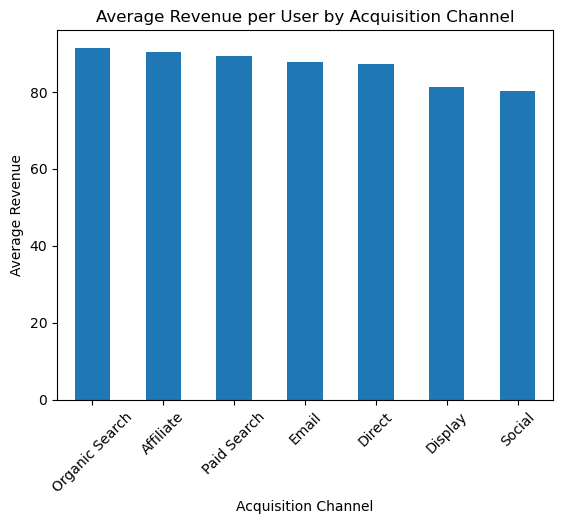

In [35]:
avg_revenue_by_channel["avg_revenue"].plot(kind="bar")

plt.title("Average Revenue per User by Acquisition Channel")
plt.ylabel("Average Revenue")
plt.xlabel("Acquisition Channel")
plt.xticks(rotation=45)

plt.show()

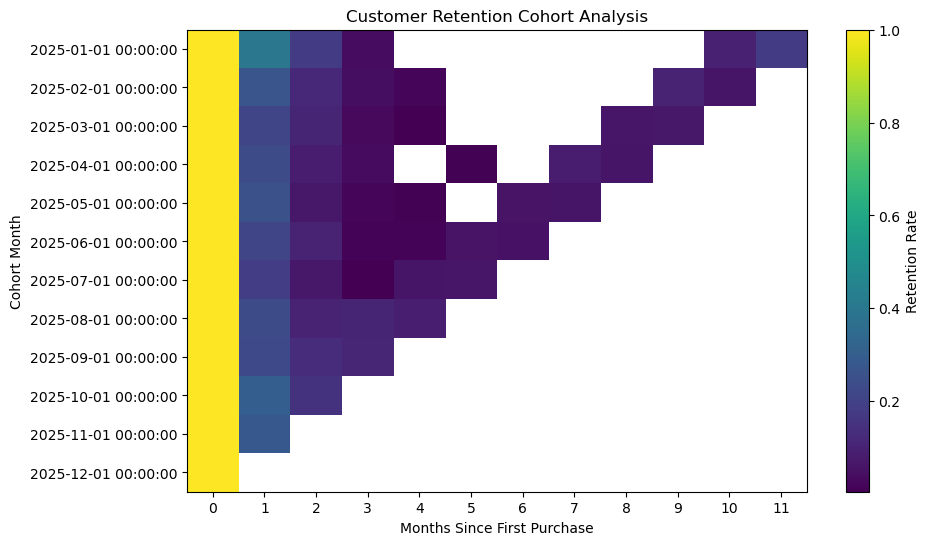

In [40]:
retention_matrix = retention_df.pivot(
    index="cohort_month",
    columns="month_number",
    values="retention_rate"
)


plt.figure(figsize=(10,6))

plt.imshow(retention_matrix, aspect="auto")

plt.colorbar(label="Retention Rate")

plt.title("Customer Retention Cohort Analysis")

plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.xticks(range(len(retention_matrix.columns)), retention_matrix.columns)
plt.yticks(range(len(retention_matrix.index)), retention_matrix.index)

plt.show()

##### Insight

--------------------------------------------------------------------------------------------------------------------------------